/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_39636/2910316243.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_39636/2910316243.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").agg({"y": "sum"})
10:18:53 - cmdstanpy - INFO - Chain [1] start processing


Monthly splits: Train= 90 Val= 6 Test= 6
Weekly splits:  Train= 400 Val= 13 Test= 13
Daily  splits:  Train= 2875 Val= 45 Test= 47


10:18:53 - cmdstanpy - INFO - Chain [1] done processing
10:18:53 - cmdstanpy - INFO - Chain [1] start processing
10:18:53 - cmdstanpy - INFO - Chain [1] done processing
10:18:53 - cmdstanpy - INFO - Chain [1] start processing
10:18:53 - cmdstanpy - INFO - Chain [1] done processing



=== FULL TEST METRICS (RMSE, MSE, MAE, R^2, MAPE) ===
  Frequency            RMSE                        MSE             MAE  \
0   Monthly  253,376,683.77  64,199,743,877,873,440.00  184,221,240.82   
1    Weekly  144,591,012.00  20,906,560,751,819,572.00  116,942,295.28   
2     Daily   30,599,023.25     936,300,223,767,684.25   27,959,097.57   

       R^2     MAPE  
0   0.2263   13.40%  
1  -0.0659   65.99%  
2  -0.1955  373.72%  

=== 6-ROW TABLE (RMSE & RMSE/mean) ===
  Time period    Results         Prophet
0     Monthly       RMSE  253,376,683.77
1     Monthly  RMSE/mean          20.68%
2      Weekly       RMSE  144,591,012.00
3      Weekly  RMSE/mean          45.07%
4       Daily       RMSE   30,599,023.25
5       Daily  RMSE/mean          52.14%


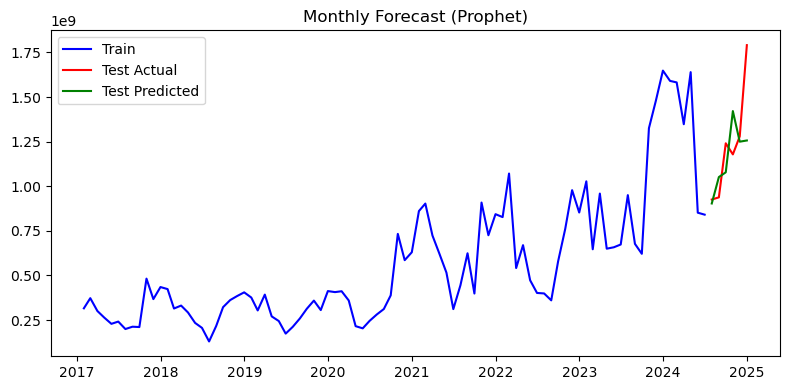

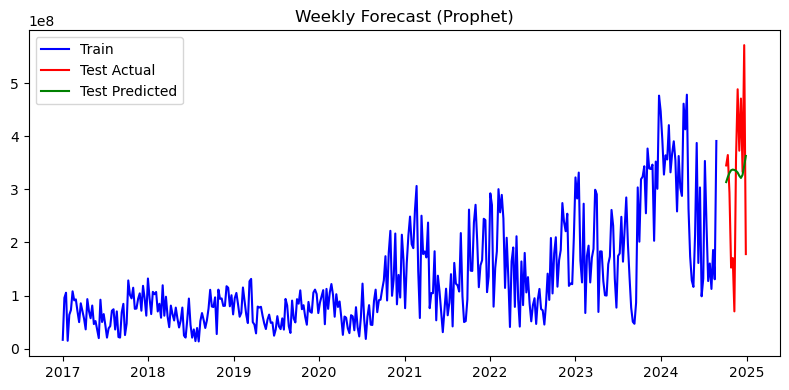

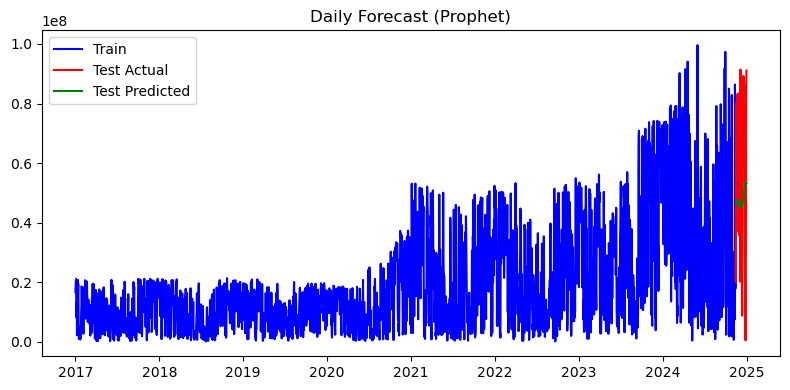

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------------------------------------------
# 1) LOAD & PREPROCESS HOURLY DATA
# -------------------------------------------------------------------
df = pd.read_csv("/Users/polina/Watts-next/data/final_offshore_data_2017_2025.csv")

# Fix “24 -> 0” hour issue
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1
df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")

# Prophet columns: ds and y
df["y"] = df["volume"]

# Sort and set ds as index
df.sort_values("ds", inplace=True)
df.set_index("ds", inplace=True)

# -------------------------------------------------------------------
# 2) CREATE MONTHLY, WEEKLY, DAILY DATAFRAMES (Sum of hours -> MWh)
# -------------------------------------------------------------------
df_monthly = df.resample("M").agg({"y": "sum"})
df_monthly["ds"] = df_monthly.index
df_monthly.reset_index(drop=True, inplace=True)

df_weekly = df.resample("W").agg({"y": "sum"})
df_weekly["ds"] = df_weekly.index
df_weekly.reset_index(drop=True, inplace=True)

df_daily = df.resample("D").agg({"y": "sum"})
df_daily["ds"] = df_daily.index
df_daily.reset_index(drop=True, inplace=True)

# -------------------------------------------------------------------
# 3) DEFINE SPLITS EXACTLY PER YOUR TABLE
# -------------------------------------------------------------------
# MONTHLY
# - Train: Jan 2017 – Jun 2024 => ds < "2024-07-01"
# - Validation (6 mo): Jan – Jun 2024 => ds in [2024-01-01, 2024-07-01)
# - Test (6 mo): Jul – Dec 2024 => ds in [2024-07-01, 2025-01-01)
train_mask_month = df_monthly["ds"] < "2024-07-01"
val_mask_month   = (df_monthly["ds"] >= "2024-01-01") & (df_monthly["ds"] < "2024-07-01")
test_mask_month  = (df_monthly["ds"] >= "2024-07-01") & (df_monthly["ds"] < "2025-01-01")

df_train_month = df_monthly.loc[train_mask_month].copy()
df_val_month   = df_monthly.loc[val_mask_month].copy()
df_test_month  = df_monthly.loc[test_mask_month].copy()

# WEEKLY
# - Train: Jan 2017 – Sep 2024 => ds < "2024-09-01"
# - Validation (12 wks): Jul – Sep 2024 => ds in [2024-07-01, 2024-10-01)
# - Test (12 wks): Oct – Dec 2024 => ds in [2024-10-01, 2025-01-01)
train_mask_week = df_weekly["ds"] < "2024-09-01"
val_mask_week   = (df_weekly["ds"] >= "2024-07-01") & (df_weekly["ds"] < "2024-10-01")
test_mask_week  = (df_weekly["ds"] >= "2024-10-01") & (df_weekly["ds"] < "2025-01-01")

df_train_week = df_weekly.loc[train_mask_week].copy()
df_val_week   = df_weekly.loc[val_mask_week].copy()
df_test_week  = df_weekly.loc[test_mask_week].copy()

# DAILY
# - Train: Jan 2017 – mid-Nov 2024 => ds < "2024-11-15"
# - Validation (42d): Oct – mid-Nov 2024 => ds in [2024-10-01, 2024-11-15)
# - Test (42d): mid-Nov – Dec 2024 => ds in [2024-11-15, 2025-01-01)
train_mask_day = df_daily["ds"] < "2024-11-15"
val_mask_day   = (df_daily["ds"] >= "2024-10-01") & (df_daily["ds"] < "2024-11-15")
test_mask_day  = (df_daily["ds"] >= "2024-11-15") & (df_daily["ds"] < "2025-01-01")

df_train_day = df_daily.loc[train_mask_day].copy()
df_val_day   = df_daily.loc[val_mask_day].copy()
df_test_day  = df_daily.loc[test_mask_day].copy()

print("Monthly splits: Train=", len(df_train_month), "Val=", len(df_val_month), "Test=", len(df_test_month))
print("Weekly splits:  Train=", len(df_train_week),  "Val=", len(df_val_week),  "Test=", len(df_test_week))
print("Daily  splits:  Train=", len(df_train_day),   "Val=", len(df_val_day),   "Test=", len(df_test_day))

# -------------------------------------------------------------------
# 4) TRAIN PROPHET MODELS (Monthly, Weekly, Daily)
# -------------------------------------------------------------------
model_month = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_month.fit(df_train_month[["ds","y"]])

model_week = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_week.fit(df_train_week[["ds","y"]])

model_day = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_day.fit(df_train_day[["ds","y"]])

# -------------------------------------------------------------------
# 5) PREDICT & COMPUTE TEST METRICS FOR EACH FREQUENCY
# -------------------------------------------------------------------
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

# A) MONTHLY
test_pred_month = model_month.predict(df_test_month[["ds"]])
df_test_month_merged = df_test_month.merge(test_pred_month[["ds","yhat"]], on="ds", how="left")
y_true_mo = df_test_month_merged["y"].values
y_hat_mo  = df_test_month_merged["yhat"].values

mse_mo  = mean_squared_error(y_true_mo, y_hat_mo)
rmse_mo = np.sqrt(mse_mo)
mae_mo  = mean_absolute_error(y_true_mo, y_hat_mo)
r2_mo   = r2_score(y_true_mo, y_hat_mo)
mape_mo = mape(y_true_mo, y_hat_mo)

# B) WEEKLY
test_pred_week = model_week.predict(df_test_week[["ds"]])
df_test_week_merged = df_test_week.merge(test_pred_week[["ds","yhat"]], on="ds", how="left")
y_true_wk = df_test_week_merged["y"].values
y_hat_wk  = df_test_week_merged["yhat"].values

mse_wk  = mean_squared_error(y_true_wk, y_hat_wk)
rmse_wk = np.sqrt(mse_wk)
mae_wk  = mean_absolute_error(y_true_wk, y_hat_wk)
r2_wk   = r2_score(y_true_wk, y_hat_wk)
mape_wk = mape(y_true_wk, y_hat_wk)

# C) DAILY
test_pred_day = model_day.predict(df_test_day[["ds"]])
df_test_day_merged = df_test_day.merge(test_pred_day[["ds","yhat"]], on="ds", how="left")
y_true_d = df_test_day_merged["y"].values
y_hat_d  = df_test_day_merged["yhat"].values

mse_d  = mean_squared_error(y_true_d, y_hat_d)
rmse_d = np.sqrt(mse_d)
mae_d  = mean_absolute_error(y_true_d, y_hat_d)
r2_d   = r2_score(y_true_d, y_hat_d)
mape_d = mape(y_true_d, y_hat_d)

# -------------------------------------------------------------------
# 6) BUILD THE MULTI-METRIC TABLE (RMSE, MSE, MAE, R^2, MAPE)
# -------------------------------------------------------------------
summary_data = {
    "Frequency": ["Monthly", "Weekly", "Daily"],
    "RMSE":  [f"{rmse_mo:,.2f}", f"{rmse_wk:,.2f}", f"{rmse_d:,.2f}"],
    "MSE":   [f"{mse_mo:,.2f}",  f"{mse_wk:,.2f}",  f"{mse_d:,.2f}"],
    "MAE":   [f"{mae_mo:,.2f}",  f"{mae_wk:,.2f}",  f"{mae_d:,.2f}"],
    "R^2":   [f"{r2_mo:.4f}",    f"{r2_wk:.4f}",    f"{r2_d:.4f}"],
    "MAPE":  [f"{mape_mo:,.2f}%", f"{mape_wk:,.2f}%", f"{mape_d:,.2f}%"],
}
df_summary = pd.DataFrame(summary_data)
print("\n=== FULL TEST METRICS (RMSE, MSE, MAE, R^2, MAPE) ===")
print(df_summary)

# -------------------------------------------------------------------
# 7) ADD THE 6-ROW TABLE (RMSE and RMSE/mean) FOR MONTHLY/WEEKLY/DAILY
# -------------------------------------------------------------------
# We'll compute the test set mean 'y' to get "RMSE/mean" in %.
mean_mo = df_test_month_merged["y"].mean()
mean_wk = df_test_week_merged["y"].mean()
mean_d  = df_test_day_merged["y"].mean()

rmse_over_mean_mo = (rmse_mo / mean_mo) * 100
rmse_over_mean_wk = (rmse_wk / mean_wk) * 100
rmse_over_mean_d  = (rmse_d  / mean_d ) * 100

table_data_rmse = {
    "Time period": [
        "Monthly", "Monthly",
        "Weekly",  "Weekly",
        "Daily",   "Daily"
    ],
    "Results": [
        "RMSE",
        "RMSE/mean",
        "RMSE",
        "RMSE/mean",
        "RMSE",
        "RMSE/mean"
    ],
    "Prophet": [
        f"{rmse_mo:,.2f}",            # monthly RMSE
        f"{rmse_over_mean_mo:,.2f}%", # monthly RMSE/mean
        f"{rmse_wk:,.2f}",            # weekly RMSE
        f"{rmse_over_mean_wk:,.2f}%", # weekly RMSE/mean
        f"{rmse_d:,.2f}",             # daily RMSE
        f"{rmse_over_mean_d:,.2f}%",  # daily RMSE/mean
    ]
}
df_results_rmse = pd.DataFrame(table_data_rmse)
print("\n=== 6-ROW TABLE (RMSE & RMSE/mean) ===")
print(df_results_rmse)

# -------------------------------------------------------------------
# 8) OPTIONAL: PLOT (TRAIN in BLUE, TEST ACTUAL in RED, TEST PREDICTED in GREEN)
# -------------------------------------------------------------------
# MONTHLY
plt.figure(figsize=(8,4))
plt.plot(df_train_month["ds"], df_train_month["y"], color="blue", label="Train")
plt.plot(df_test_month_merged["ds"], df_test_month_merged["y"], color="red", label="Test Actual")
plt.plot(df_test_month_merged["ds"], df_test_month_merged["yhat"], color="green", label="Test Predicted")
plt.title("Monthly Forecast (Prophet)")
plt.legend()
plt.tight_layout()
plt.show()

# WEEKLY
plt.figure(figsize=(8,4))
plt.plot(df_train_week["ds"], df_train_week["y"], color="blue", label="Train")
plt.plot(df_test_week_merged["ds"], df_test_week_merged["y"], color="red", label="Test Actual")
plt.plot(df_test_week_merged["ds"], df_test_week_merged["yhat"], color="green", label="Test Predicted")
plt.title("Weekly Forecast (Prophet)")
plt.legend()
plt.tight_layout()
plt.show()

# DAILY
plt.figure(figsize=(8,4))
plt.plot(df_train_day["ds"], df_train_day["y"], color="blue", label="Train")
plt.plot(df_test_day_merged["ds"], df_test_day_merged["y"], color="red", label="Test Actual")
plt.plot(df_test_day_merged["ds"], df_test_day_merged["yhat"], color="green", label="Test Predicted")
plt.title("Daily Forecast (Prophet)")
plt.legend()
plt.tight_layout()
plt.show()
